# Risk Predictor Training Demo
This notebook is aligned with runtime deployment: seq2seq model, 16-frame window, 12-frame burn-in, and 4-frame prediction.
It keeps DataLoader throughput settings (`num_workers`, `prefetch_factor`, `persistent_workers`) for stable multi-epoch training.

In [2]:
from MIREIA.perception.climate_model_train import train_environment_model

result = train_environment_model(
    epochs=1,
    batch_size=256,
    lr=1e-4,
    weight_decay=1e-4,
    num_workers=16,
    prefetch_factor=1,
    disable_amp=False,
    log_every=25,
    grad_accum_steps=1,
    grad_clip=None,
    image_size=512,
    dropout=0.2,
    day_loss_weight=1.0,
    weather_loss_weight=1.0,
    scenarios_root=None,
    subset_ratio=None,
    subset_seed=42,
    subset_mode="first",
    max_scenarios=None,
    frame_subset_ratio=None,
    frame_subset_seed=42,
    frame_subset_mode="random",
    checkpoint_path="",
    checkpoint_name="environment_multitask_checkpoint.pt",
    no_resume=False,
    device="",
    resize_images=False,
 )

print("Saved:", result["checkpoint_path"])
print("Classes:", result["idx_to_climate"])
print("Final epoch:", result["final_epoch"])

Resuming from t:\TFG\MIREIA\models\environment_multitask_checkpoint.pt at epoch 2


RuntimeError: Caught RuntimeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "t:\TFG\env\Lib\site-packages\torch\utils\data\_utils\worker.py", line 351, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "t:\TFG\env\Lib\site-packages\torch\utils\data\_utils\fetch.py", line 55, in fetch
    return self.collate_fn(data)
           ^^^^^^^^^^^^^^^^^^^^^
  File "t:\TFG\env\Lib\site-packages\torch\utils\data\_utils\collate.py", line 398, in default_collate
    return collate(batch, collate_fn_map=default_collate_fn_map)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "t:\TFG\env\Lib\site-packages\torch\utils\data\_utils\collate.py", line 212, in collate
    collate(samples, collate_fn_map=collate_fn_map)
  File "t:\TFG\env\Lib\site-packages\torch\utils\data\_utils\collate.py", line 155, in collate
    return collate_fn_map[elem_type](batch, collate_fn_map=c

In [1]:
import torch
torch.backends.cudnn.benchmark = True

from torchvision import transforms

from MIREIA.config import Config
from MIREIA.perception.e2e_model import E2EModelConfig, E2ERiskPredictor, Seq2SeqRiskPredictor
from MIREIA.perception.training_utils import (
    build_scenario_dataloaders,
    load_checkpoint,
    save_checkpoint,
    train_model,
 )

 # Runtime-aligned training setup (matches streaming inference path).
import os

model_type = "seq2seq"  # use seq2seq for FIFO temporal deployment
m_eval_frames = Config.INFERENCE_EVAL_FRAMES  # expected: 4
seq_len = Config.INFERENCE_SEQUENCE_LENGTH  # expected: 16
burn_in_frames = Config.INFERENCE_BURN_IN_FRAMES  # expected: 12
if burn_in_frames + m_eval_frames != seq_len:
    raise ValueError(
        f"Invalid temporal setup: burn_in({burn_in_frames}) + eval({m_eval_frames}) != seq_len({seq_len})"
    )

In [2]:


# Throughput-focused defaults (adjust if you hit OOM).
batch_size = 8  # was 2; increase to better saturate GPU
num_workers = 8
prefetch_factor = 4  # batches prefetched per worker
pin_memory = True
persistent_workers = True  # keep workers alive across epochs for throughput


iterations = 1


for i in range(iterations):
    window_subset_ratio = None# 0.25  # set None for full dataset
    window_subset_mode = "random"  # "random" or "first"
    window_subset_seed = 20 + iterations  # Config.RANDOM_SEED

    # Reuse the default dataset transform
    transform = transforms.Compose(
        [
            #transforms.Resize((512, 512)),
            transforms.ToTensor(),
        ]
    )

    train_loader, val_loader, target_mode = build_scenario_dataloaders(
        seq_len=seq_len,
        batch_size=batch_size,
        num_workers=num_workers,
        prefetch_factor=prefetch_factor,
        pin_memory=pin_memory,
        persistent_workers=persistent_workers,
        transform=transform,
        model_type=model_type,
        m_eval_frames=m_eval_frames,
        window_subset_ratio=window_subset_ratio,
        window_subset_mode=window_subset_mode,
        window_subset_seed=window_subset_seed,
    )

    print(f"Temporal config: seq_len={seq_len}, burn_in={burn_in_frames}, eval={m_eval_frames}")
    print(f"DataLoader workers: num_workers={num_workers}, prefetch_factor={prefetch_factor}, persistent_workers={persistent_workers}")
    print(f"Train batches: {len(train_loader)}")
    print(f"Val batches: {len(val_loader)}")

    batch_x, batch_y = next(iter(train_loader))
    print("Batch X shape:", batch_x.shape)
    print("Batch Y shape:", batch_y.shape)
    print("Batch X dtype:", batch_x.dtype)
    print("Batch Y dtype:", batch_y.dtype)

    # Resume training from checkpoint if available
    import os
    import torch
    from torch import nn, optim

    resume_epochs = 1  # number of epochs to train after resuming

    if not torch.cuda.is_available():
        raise RuntimeError("CUDA is not available. Install a CUDA-enabled PyTorch build or check your GPU drivers.")

    device = torch.device("cuda")
    if model_type == "seq2seq":
        model = Seq2SeqRiskPredictor(E2EModelConfig()).to(device)
    else:
        model = E2ERiskPredictor(E2EModelConfig()).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.MSELoss()

    # Keep resume path aligned with initial save cell
    if "checkpoint_path" not in globals():
        checkpoint_name = "seq2seq_risk_checkpoint.pt" if model_type == "seq2seq" else "single_checkpoint.pt"
        checkpoint_path = os.path.join(Config.PATH_TO_MODELS, checkpoint_name)

    use_amp = True

    start_epoch = 1
    history = {"train_loss": [], "val_loss": []}
    if os.path.exists(checkpoint_path):
        ckpt = load_checkpoint(checkpoint_path, model, optimizer=optimizer, device=device)
        history = ckpt.get("history", history)
        start_epoch = ckpt.get("epoch", 0) + 1
        model_type = ckpt.get("model_type", model_type)
        m_eval_frames = ckpt.get("m_eval_frames", m_eval_frames)
        print(f"Resuming from {checkpoint_path} at epoch {start_epoch}")
    else:
        print("No checkpoint found. Starting fresh.")

    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        device=device,
        criterion=criterion,
        epochs=resume_epochs,
        start_epoch=start_epoch,
        history=history,
        model_type=model_type,
        m_eval_frames=m_eval_frames,
        use_amp=use_amp,
    )

    save_checkpoint(
        checkpoint_path=checkpoint_path,
        model=model,
        optimizer=optimizer,
        history=history,
        epoch=start_epoch + resume_epochs - 1,
        extra={
            "model_type": model_type,
            "m_eval_frames": m_eval_frames,
            "seq_len": seq_len,
            "target_mode": target_mode,
            "use_amp": use_amp,
        },
    )
    print(f"Saved checkpoint: {checkpoint_path}")

Temporal config: seq_len=16, burn_in=12, eval=4
DataLoader workers: num_workers=8, prefetch_factor=4, persistent_workers=True
Train batches: 24199
Val batches: 4482
Batch X shape: torch.Size([8, 16, 3, 512, 512])
Batch Y shape: torch.Size([8, 16, 1])
Batch X dtype: torch.float32
Batch Y dtype: torch.float32


t:\TFG\MIREIA\perception\training_utils.py:270: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(checkpoint_path, map_location=device)


Resuming from t:\TFG\MIREIA\models\seq2seq_risk_checkpoint.pt at epoch 21


t:\TFG\MIREIA\perception\training_utils.py:104: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)


Batch 1/24199 | avg loss: 0.711628 | batch shape: (8, 16, 3, 512, 512) | ETA: 168323.3s (2805.4m)
Batch 25/24199 | avg loss: 1.908450 | batch shape: (8, 16, 3, 512, 512) | ETA: 13182.6s (219.7m)
Batch 50/24199 | avg loss: 2.739639 | batch shape: (8, 16, 3, 512, 512) | ETA: 9982.3s (166.4m)
Batch 75/24199 | avg loss: 2.620765 | batch shape: (8, 16, 3, 512, 512) | ETA: 8898.5s (148.3m)
Batch 100/24199 | avg loss: 2.309668 | batch shape: (8, 16, 3, 512, 512) | ETA: 8333.6s (138.9m)
Batch 125/24199 | avg loss: 2.412186 | batch shape: (8, 16, 3, 512, 512) | ETA: 7992.8s (133.2m)
Batch 150/24199 | avg loss: 2.406135 | batch shape: (8, 16, 3, 512, 512) | ETA: 7751.0s (129.2m)
Batch 175/24199 | avg loss: 2.236798 | batch shape: (8, 16, 3, 512, 512) | ETA: 7572.5s (126.2m)
Batch 200/24199 | avg loss: 2.238849 | batch shape: (8, 16, 3, 512, 512) | ETA: 7460.9s (124.3m)
Batch 225/24199 | avg loss: 2.190781 | batch shape: (8, 16, 3, 512, 512) | ETA: 7354.4s (122.6m)
Batch 250/24199 | avg loss: 2.1

In [3]:
# Summary metrics (run after training)
train_samples = len(train_loader.dataset)
val_samples = len(val_loader.dataset) if val_loader is not None else 0
print(f"Train samples: {train_samples}")
print(f"Val samples:   {val_samples}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

if "history" in globals() and history.get("train_loss"):
    best_train = min(history["train_loss"])
    print(f"Best train loss: {best_train:.6f}")
if "history" in globals() and history.get("val_loss"):
    best_val = min(history["val_loss"])
    print(f"Best val loss:   {best_val:.6f}")

if torch.cuda.is_available():
    mem_alloc = torch.cuda.max_memory_allocated() / (1024 ** 3)
    mem_reserved = torch.cuda.max_memory_reserved() / (1024 ** 3)
    print(f"Peak CUDA allocated: {mem_alloc:.2f} GB")
    print(f"Peak CUDA reserved:  {mem_reserved:.2f} GB")

Train samples: 193590
Val samples:   35850
Train batches: 24199
Val batches:   4482
Best train loss: 0.569618
Best val loss:   5.736896
Peak CUDA allocated: 9.68 GB
Peak CUDA reserved:  10.94 GB


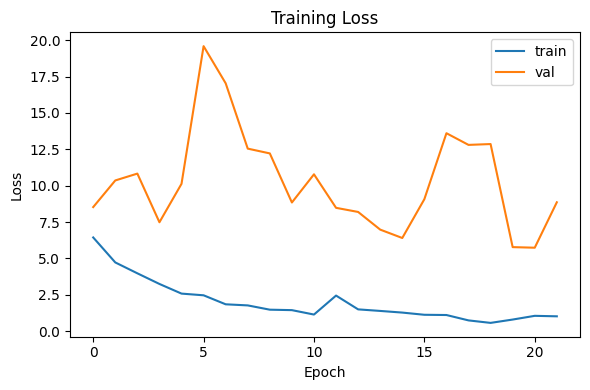

In [4]:
import matplotlib.pyplot as plt

if "history" in globals() and history.get("train_loss"):
    plt.figure(figsize=(6, 4))
    plt.plot(history["train_loss"], label="train")
    if history.get("val_loss"):
        plt.plot(history["val_loss"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No training history found. Run the training cell first.")

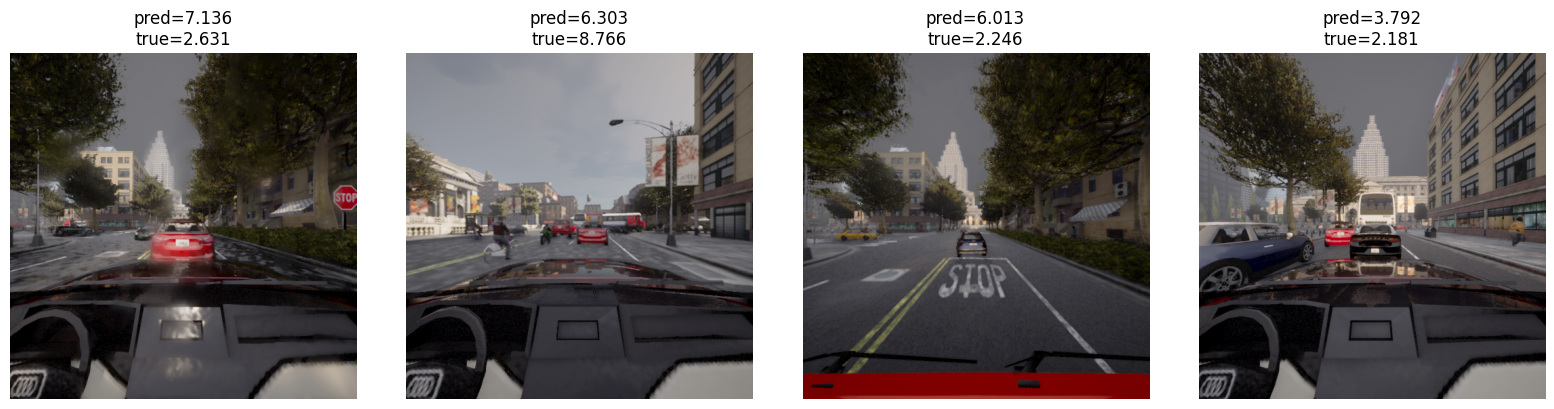

In [5]:
import matplotlib.pyplot as plt
import torch
import random

if "model" not in globals():
    print("Model not found. Run the training cell first.")
else:
    model.eval()
    dataset = val_loader.dataset if val_loader is not None else train_loader.dataset
    n_show = 4
    rng = random.Random(Config.RANDOM_SEED)
    indices = rng.sample(range(len(dataset)), k=min(n_show, len(dataset)))
    sequences = [dataset[idx] for idx in indices]
    batch_x = torch.stack([seq for seq, _ in sequences], dim=0)
    batch_y = torch.stack([target for _, target in sequences], dim=0)

    inference_device = device if "device" in globals() else torch.device("cuda" if torch.cuda.is_available() else "cpu")
    with torch.no_grad():
        if model_type == "seq2seq":
            preds = model(batch_x.to(inference_device, non_blocking=True), m_eval_frames=m_eval_frames).cpu()
            # use latest predicted frame (Risk_t) from the eval window
            pred_vals = preds[:, -1, 0] if preds.ndim == 3 else preds.squeeze(1)
        else:
            preds = model(batch_x.to(inference_device, non_blocking=True)).cpu().squeeze(1)
            pred_vals = preds

    if batch_y.ndim == 3:
        target_vals = batch_y[:, -1, 0]
    else:
        target_vals = batch_y.squeeze(1)

    fig, axes = plt.subplots(1, len(indices), figsize=(4 * len(indices), 4))
    if len(indices) == 1:
        axes = [axes]
    for i in range(len(indices)):
        frame0 = batch_x[i, -1].permute(1, 2, 0).cpu()  # show most recent frame in sequence
        axes[i].imshow(frame0)
        axes[i].axis("off")
        axes[i].set_title(f"pred={pred_vals[i]:.3f}\ntrue={target_vals[i]:.3f}")
    plt.tight_layout()
    plt.show()